In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training.train_state import TrainState

from flightning import FLIGHTNING_PATH
from flightning.algos import bptt
from flightning.envs import HoveringStateEnv, rollout
from flightning.envs.wrappers import MinMaxObservationWrapper
from flightning.modules import MLP

%matplotlib inline

2025-09-15 16:25:26.992973: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Training a State-based Quadrotor Policy With BPTT

## Seed it

In [2]:
seed = 0
key = jax.random.key(seed)
key_init, key_bptt = jax.random.split(key, 2)

## Setup the Training Environment

In [3]:
drone_path = FLIGHTNING_PATH + "/objects/quadrotor_files/example_quad.yaml"
dt = 0.02

env = HoveringStateEnv(
    max_steps_in_episode=3 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=0.1,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
)
env = MinMaxObservationWrapper(env)

# get dims
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]

236


## Define the Policy Network

In [4]:
policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    initial_scale=0.01,
    action_bias=env.hovering_action,
)
policy_params = policy_net.initialize(key_init)

## Setup the Optimizer and Train State

In [5]:
N = 1000
scheduler = optax.cosine_decay_schedule(1e-2, N)
tx = optax.adam(scheduler)
train_state = TrainState.create(
    apply_fn=policy_net.apply, params=policy_params, tx=tx
)

## Initial Rollout

In [6]:
def get_rollouts(env, policy, num_rollouts, key):
    parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None))
    rollout_keys = jax.random.split(key, num_rollouts)
    transitions = parallel_rollout(env, rollout_keys, policy)
    return transitions


def policy(obs, key):
    return train_state.apply_fn(train_state.params, obs)

transitions = get_rollouts(env, policy, 10, jax.random.key(3))

/home/yanrui/tempstorage4/rpg_flightning/flightning/envs/hovering_state_env.py:440: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


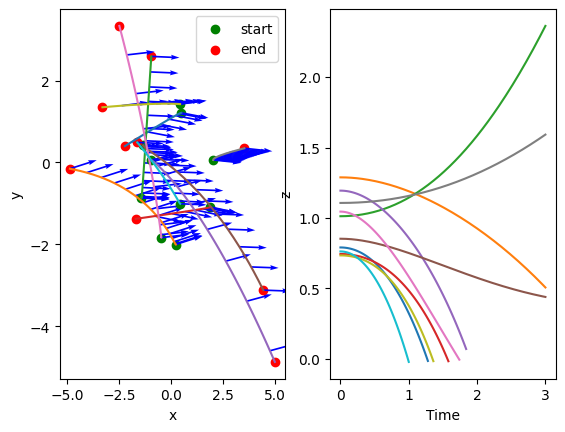

In [7]:
env.plot_trajectories(transitions)

## Train the Policy Using BPTT

In [8]:
time_start = time.time()
res_dict = bptt.train(
    env,
    train_state,
    num_epochs=1000,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=100,
    key=key_bptt,
)
time_train = time.time() - time_start
print(f"Training time: {time_train}")

Episode: 0, Grad max: 7.2646
Episode: 0, Loss: 62.57
Episode: 10, Grad max: 11.6397
Episode: 10, Loss: 60.73
Episode: 20, Grad max: 7.1882
Episode: 20, Loss: 26.76
Episode: 30, Grad max: 3.9052
Episode: 30, Loss: 20.16
Episode: 40, Grad max: 5.0215
Episode: 40, Loss: 17.82
Episode: 50, Grad max: 4.2871
Episode: 50, Loss: 15.50
Episode: 60, Grad max: 3.6267
Episode: 60, Loss: 12.61
Episode: 70, Grad max: 1.0576
Episode: 70, Loss: 12.09
Episode: 80, Grad max: 0.9572
Episode: 80, Loss: 10.69
Episode: 90, Grad max: 1.3007
Episode: 90, Loss: 11.44
Episode: 100, Grad max: 1.3123
Episode: 100, Loss: 10.38
Episode: 110, Grad max: 0.9474
Episode: 110, Loss: 10.42
Episode: 120, Grad max: 1.7406
Episode: 120, Loss: 10.26
Episode: 130, Grad max: 1.6221
Episode: 130, Loss: 10.09
Episode: 140, Grad max: 2.5773
Episode: 140, Loss: 10.46
Episode: 150, Grad max: 2.4920
Episode: 150, Loss: 10.61
Episode: 160, Grad max: 1.7724
Episode: 160, Loss: 10.15
Episode: 170, Grad max: 1.5202
Episode: 170, Loss: 9

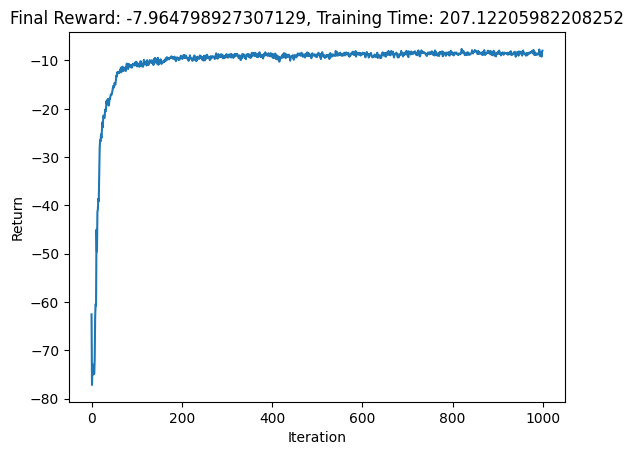

In [9]:
rewards = -res_dict["metrics"]
plt.plot(rewards)
plt.title(f"Final Reward: {rewards[-1]}, Training Time: {time_train}")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.show()

## Evaluate the Trained Policy

In [10]:
new_train_state = res_dict["runner_state"].train_state

def policy_trained(obs, key):
    return train_state.apply_fn(new_train_state.params, obs)

In [11]:
env_eval = HoveringStateEnv(
    max_steps_in_episode=6 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.05,
    yaw_scale=0.05,
    pitch_roll_scale=0.05,
    omega_std=0.05,
    drone_path=drone_path,
)
env_eval = MinMaxObservationWrapper(env_eval)
transitions_eval = get_rollouts(env_eval, policy_trained, 20, jax.random.key(3))

236


/home/yanrui/tempstorage4/rpg_flightning/flightning/envs/hovering_state_env.py:440: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


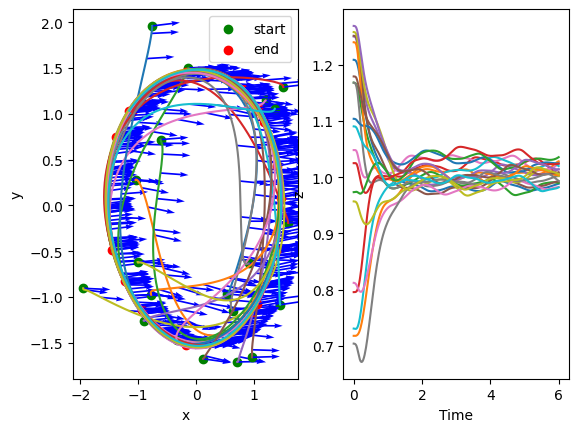

In [12]:
env_eval.plot_trajectories(transitions_eval)

In [13]:
transitions_eval.state.quadrotor_state.v[1][-1,:]

Array([ 2.0829313 , -0.3547917 ,  0.02245325], dtype=float32)

In [14]:
transitions_eval.state.quadrotor_state.time_elapsed[1][-1]

AttributeError: 'QuadrotorState' object has no attribute 'time_elapsed'

In [15]:
from orbax.checkpoint import PyTreeCheckpointer
path = FLIGHTNING_PATH + "/../examples/saved_params"
ckptr = PyTreeCheckpointer()
ckptr.save(path, new_train_state.params)

In [ ]:
train_state.apply_fn(new_train_state.params, transitions_eval.obs[10][-14])